# Calibrated viscous damping per DOF — plots in degrees

Reproduces the three damping figures from `damping_summary_all_dofs.xlsx`:

1. Calibrated **viscous** damping per DOF
2. Calibrated damping **including radiation damping** (total)  *(Figure 3.8)*
3. Total damping with **per-construction means + global mean** *(Figure 3.9)*

**Unit conversion (rad → deg).** Heave is translational and stays in `kN/(m/s)` /
`kN/(m/s)²`. Pitch and roll are rotational and are converted from `rad` to `deg`:

- linear:    $B_\ell^{[\deg]} = B_\ell^{[\mathrm{rad}]}\cdot(\pi/180)$ → `kNm/(deg/s)`
- quadratic: $B_q^{[\deg]} = B_q^{[\mathrm{rad}]}\cdot(\pi/180)^2$ → `kNm/(deg/s)²`

The factor differs because the moment is $M = B_\ell\,\dot\theta + B_q\,\dot\theta|\dot\theta|$:
replacing $\dot\theta_{\mathrm{rad}} = (\pi/180)\,\dot\theta_{\deg}$ gives one power of
$\pi/180$ on the linear term and two on the quadratic term.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX = "damping_summary_all_dofs.xlsx"   # adjust path if needed

ind  = pd.read_excel(XLSX, sheet_name="individual_results_all_dofs")
mpc  = pd.read_excel(XLSX, sheet_name="mean_per_construction_dof")
glob = pd.read_excel(XLSX, sheet_name="overall_mean_per_dof")


## Apply the rad → deg conversion (pitch & roll only)

In [16]:
DEG  = np.pi / 180.0          # linear   coefficient factor
DEG2 = (np.pi / 180.0) ** 2   # quadratic coefficient factor
ROT  = {"pitch", "roll"}      # rotational DOFs; heave is left unchanged

def convert(df, lin_cols, quad_cols):
    "Multiply rotational-DOF rows by the rad->deg factors."
    df = df.copy()
    rot = df["dof"].isin(ROT)
    for c in lin_cols:
        df.loc[rot, c] *= DEG
    for c in quad_cols:
        df.loc[rot, c] *= DEG2
    return df

ind = convert(ind,
              ["linear_damping", "total_linear_damping"],
              ["quadratic_damping", "total_quadratic_damping"])
mpc = convert(mpc,
              ["mean_viscous_linear_damping", "mean_total_linear_damping"],
              ["mean_viscous_quadratic_damping", "mean_total_quadratic_damping"])
glob = convert(glob,
               ["viscous_linear_damping", "total_linear_damping"],
               ["viscous_quadratic_damping", "total_quadratic_damping"])


## Plot configuration

In [17]:
DOFS = ["heave", "pitch", "roll"]
CON  = ["spring", "fixedwith", "fixedwithout"]
COL  = {"spring": "tab:blue", "fixedwith": "tab:orange", "fixedwithout": "tab:green"}
LAB  = {"spring": "Spring with deck",
        "fixedwith": "Fixed with deck",
        "fixedwithout": "Fixed without deck"}

plt.rcParams.update({"font.size": 11})

def units(dof):
    "Axis unit labels: heave translational, pitch/roll in degrees."
    if dof == "heave":
        return "kN/(m/s)", "kN/(m/s)$^2$"
    return "kNm/(deg/s)", "kNm/(deg/s)$^2$"


## Figure 1 — Calibrated viscous damping values per DOF

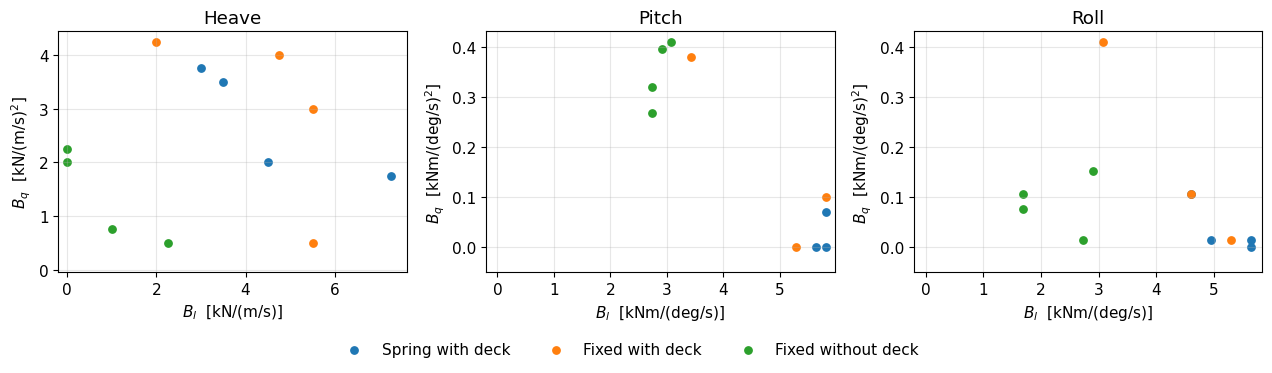

In [18]:
def plot_individual(df, xcol, ycol, prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, dof in zip(axes, DOFS):
        sub = df[df["dof"] == dof]
        for c in CON:
            s = sub[sub["construction"] == c]
            ax.scatter(s[xcol], s[ycol], color=COL[c], label=LAB[c], s=28)
        lx, ly = units(dof)
        ax.set_title(dof.capitalize())
        ax.set_xlabel(f"$B_l$  [{lx}]")
        ax.set_ylabel(f"$B_q$  [{ly}]")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=-0.2)
        ax.set_ylim(bottom=-0.05)
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig

plot_individual(ind, "linear_damping", "quadratic_damping",
                "Calibrated viscous damping values per DOF")
plt.show()


## Figure 2 (3.8) — Including radiation damping (total)

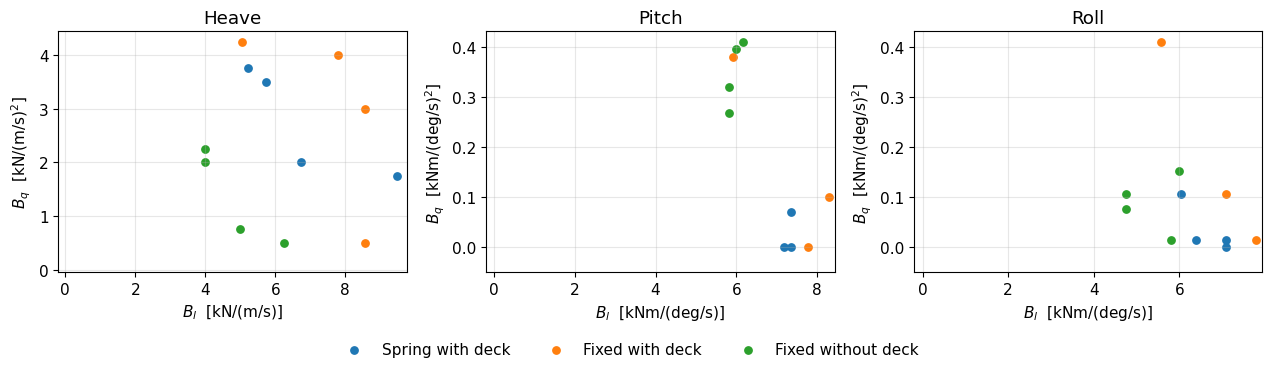

In [19]:
plot_individual(ind, "total_linear_damping", "total_quadratic_damping",
                prefix="total ")
plt.show()


## Figure 3 (3.9) — Total damping with per-construction means and global mean

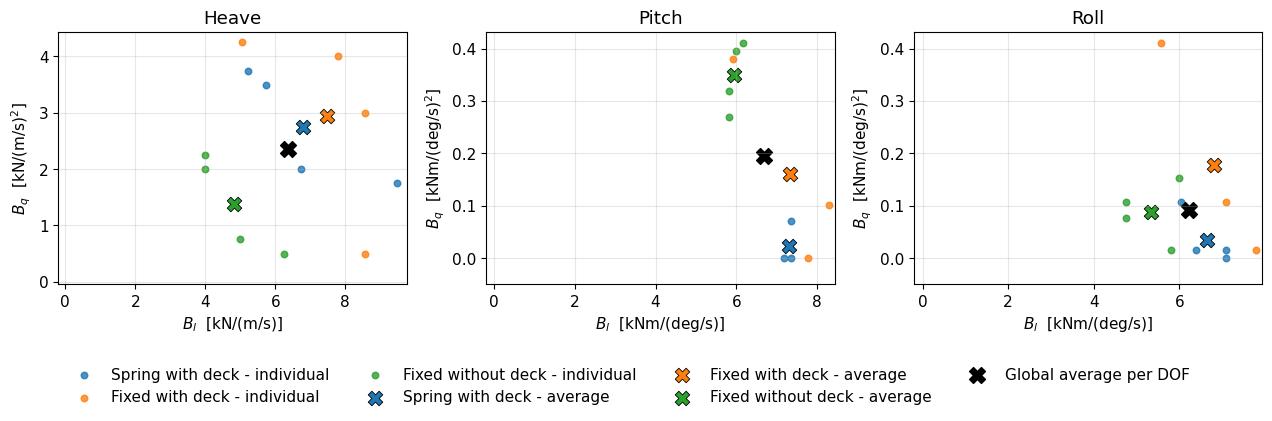

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, dof in zip(axes, DOFS):
    # individual tests (small dots)
    sub = ind[ind["dof"] == dof]
    for c in CON:
        s = sub[sub["construction"] == c]
        ax.scatter(s["total_linear_damping"], s["total_quadratic_damping"],
                   color=COL[c], s=22, alpha=0.8,
                   label=f"{LAB[c]} - individual")
    # per-construction means (coloured X)
    m = mpc[mpc["dof"] == dof]
    for c in CON:
        r = m[m["construction"] == c]
        ax.scatter(r["mean_total_linear_damping"], r["mean_total_quadratic_damping"],
                   color=COL[c], marker="X", s=110, edgecolor="k", linewidth=0.6,
                   label=f"{LAB[c]} - average")
    # global mean per DOF (black X)
    g = glob[glob["dof"] == dof]
    ax.scatter(g["total_linear_damping"], g["total_quadratic_damping"],
               color="black", marker="X", s=130, label="Global average per DOF")
    lx, ly = units(dof)
    ax.set_title(dof.capitalize())
    ax.set_xlabel(f"$B_l$  [{lx}]")
    ax.set_ylabel(f"$B_q$  [{ly}]")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=-0.2)
    ax.set_ylim(bottom=-0.05)

# de-duplicated legend
h, l = axes[0].get_legend_handles_labels()
uniq = dict(zip(l, h))
fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()
